### ロボットアーム - Panda Gym

In [1]:
import numpy as np
import gymnasium as gym
import panda_gym
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

from irl_algo import IRLTrainer

# 日本語フォント設定（japanize_matplotlibで文字化け防止）
import matplotlib
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    print("japanize_matplotlib が見つかりません。必要に応じて `pip install japanize_matplotlib` を実行してください。")

# マイナス記号を正しく表示
matplotlib.rcParams['axes.unicode_minus'] = False


<div style="font-size: small;">

* ロボット: Franka Emika Panda マニピュレータの操作タスクをシミュレート。
<br>

* 観測空間:
    - すべてのタスクにグリッパの位置と速度（6値）。
    - 物体を扱うタスクでは位置・姿勢・線形/回転速度が追加（物体1つにつき12値）。
    - グリッパ開閉距離（拘束されていなければ1値）。

* 行動空間:
    - グリッパの平行移動コマンド（x, y, z の3値）。
    - グリッパ開閉コマンド（1値）。
    
* シミュレーション:
    - エージェントの1ステップあたり20タイムステップ（各2ms）。
    - インタラクション周波数は25Hz。
    - ほとんどのタスクは約2秒（50ステップ）のエピソード長。
    
* 報酬関数:
    - 既定の報酬はスパース: 目標到達（5cm 以内）なら0、それ以外は -1。
    - スパース報酬は定義が簡単だが、進捗の手掛かりが少ない。

</div>

### PandaReach-v3

<div style="font-size: small;">

* ターゲット位置は30cm × 30cm × 30cmの範囲でランダム生成され、グリッパがそこへ到達するタスク。

</div>

In [2]:
env = gym.make(
    "PandaReach-v3",
    render_mode="rgb_array",
    # renderer="OpenGL",
    # render_target_position=[0, 0.15, 0.25],
    # render_distance=0.85,
    # render_yaw=135,
    # render_pitch=-20,
)

pybullet build time: Dec  5 2025 16:32:26


argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886



観測空間: Dict('achieved_goal': Box(-10.0, 10.0, (3,), float32), 'desired_goal': Box(-10.0, 10.0, (3,), float32), 'observation': Box(-10.0, 10.0, (6,), float32))

行動空間:  Box(-1.0, 1.0, (3,), float32)

初期状態:  ({'observation': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01,  0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00], dtype=float32), 'achieved_goal': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01], dtype=float32), 'desired_goal': array([-0.05966474,  0.13846661,  0.11077123], dtype=float32)}, {'is_success': array(False)})

環境での1ステップ:  ({'observation': array([0.03984435, 0.00169285, 0.21094498, 0.14354412, 0.01360131,
       0.6241059 ], dtype=float32), 'achieved_goal': array([0.03984435, 0.00169285, 0.21094498], dtype=float32), 'desired_goal': array([-0.05966474,  0.13846661,  0.11077123], dtype=float32)}, -1.0, False, False, {'is_success': False})


レンダリングした環境: 


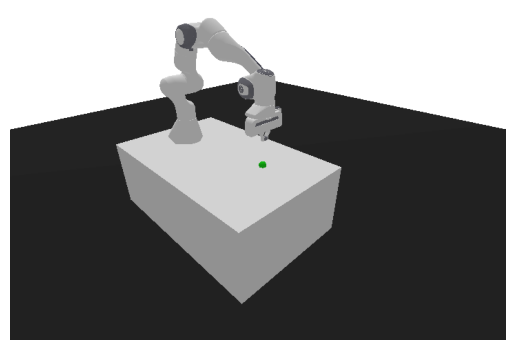

In [3]:
print('\n観測空間:', env.observation_space)
print('\n行動空間: ', env.action_space)
print('\n初期状態: ', env.reset())

# アクションは環境の期待する形状に合わせてサンプルする
sample_action = env.action_space.sample()
print('\n環境での1ステップ: ', env.step(sample_action))

print('\n\nレンダリングした環境: ')
env.reset()
plt.axis('off')
plt.imshow(env.render())
plt.show()

In [4]:
obs_shape = env.observation_space['observation'].shape[0] + \
            env.observation_space['achieved_goal'].shape[0] + \
            env.observation_space['desired_goal'].shape[0]

### 学習 - エキスパートポリシー取得

<div style="font-size: small;">

1. **初期化**:
   - ハイパーパラメータとアクター/クリティックを初期化。
   - リプレイバッファを初期化。

2. **学習ループ**:
   - エピソードを所定回数だけ繰り返す。
     - 環境をリセットして初期観測を得る。
     - エピソードが終了するまで:
       - アクター + 探索ノイズで行動を選択。
       - 行動を実行し、次状態と報酬を取得。
       - 経験 (s, a, r, s', done) をリプレイバッファへ保存。
       - HER でバッファを拡張。
       - バッファからサンプルしたミニバッチでクリティックを最適化。
       - 2回に1回の頻度でアクターを更新。
       - ターゲットアクター/クリティックをソフトアップデート。

3. **HER 拡張**:
   - 未来の状態をゴールとして再利用し、追加の学習サンプルを生成。

4. **モデル最適化**:
   - バッファに十分なサンプルがある場合にミニバッチをサンプル。
   - 2つのクリティックでターゲットQを計算し、損失を最小化。
   - クリティック2回更新につき1回アクターを更新。

5. **2つのクリティックを使う意義**:
   - min(Q1, Q2) を用いることで過大評価バイアスを抑制し、学習を安定化。
   - 2系統により過学習を抑え、局所解へのはまり込みを回避しやすくする。

</div>

In [5]:
expert = IRLTrainer(env=env, input_dims=obs_shape, agent_name='Expert', model_save_path='../IRL/Models/Expert/', 
                    exploration_period=300)

Training..:  10%|█         | 52/500 [00:07<01:02,  7.23it/s]

Episode: 50 	 Steps: 50 	 Score: -50.0 	 Recent Avg Score: -49.0 	 Success: 1/50 (2.0%)


Training..:  20%|██        | 102/500 [00:13<00:31, 12.59it/s]

Episode: 100 	 Steps: 10 	 Score: -9.0 	 Recent Avg Score: -38.7 	 Success: 14/50 (28.0%)


Training..:  30%|███       | 151/500 [00:17<00:25, 13.44it/s]

...

Training..:  81%|████████  | 403/500 [00:29<00:04, 21.67it/s]

Episode: 400 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -1.9 	 Success: 50/50 (100.0%)


Training..:  91%|█████████ | 454/500 [00:31<00:02, 21.08it/s]

Episode: 450 	 Steps: 4 	 Score: -3.0 	 Recent Avg Score: -2.0 	 Success: 50/50 (100.0%)


Training..: 100%|██████████| 500/500 [00:34<00:00, 14.63it/s]


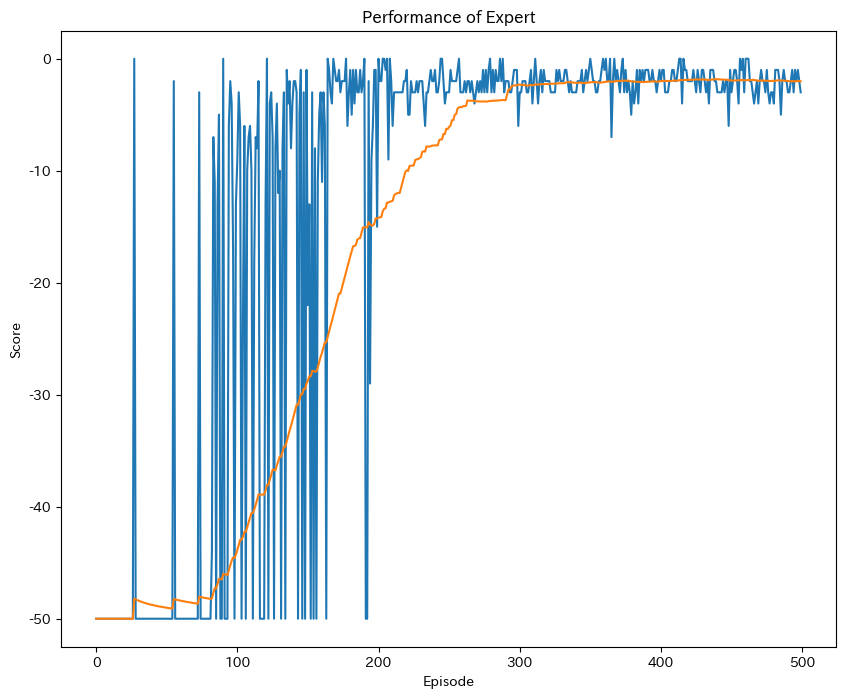

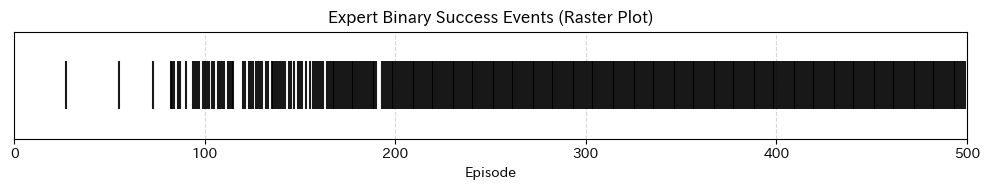

In [6]:
score_history, avg_score_history, success_history, avg_success_history = expert.irl_train(
    n_episodes=500,
    opt_steps=10,
    print_every=50,
    plot_save_path='../Results/IRL/Expert Performance.png'
)

# Plot Expert Binary Success Events (Raster Plot)
plt.figure(figsize=(10, 2))
indices = [ep for ep, val in enumerate(success_history) if val >= 0.9]
plt.eventplot([indices], lineoffsets=[0], linelengths=0.8, colors=['black'], alpha=0.9)
plt.title("Expert Binary Success Events (Raster Plot)")
plt.xlabel("Episode")
plt.yticks([])
# Use n_episodes from context if available, or just length of history
plt.xlim(0, len(success_history))
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [7]:
expert.save_model()


In [8]:
expert_reward, success = expert.test_model(env=env, steps=100, render_save_path=None, fps=5)
success_str = "成功" if success else "失敗"
print(f'エキスパートの報酬: {expert_reward:.3f} - タスク: {success_str}')


エキスパートの報酬: -2.000 - タスク: 成功


In [9]:

import matplotlib.pyplot as plt
import numpy as np

def plot_individual_performance(agent_name, score_history, success_history, window_size=50):
    # Plot 1: Scores
    plt.figure(figsize=(10, 5))
    plt.plot(score_history, alpha=0.6, label='Raw Score')
    if len(score_history) >= window_size:
        avg_scores = [np.mean(score_history[max(0, i-window_size):i+1]) for i in range(len(score_history))]
        plt.plot(avg_scores, color='red', linewidth=2, label=f'Avg Score (w={window_size})')
    plt.title(f"{agent_name} - Performance (Score)")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.xticks(np.arange(0, len(score_history)+1, 50))
    plt.show()

    # Plot 2: Success Rate Moving Average
    plt.figure(figsize=(10, 5))
    if len(success_history) >= window_size:
        avg_success = [np.mean(success_history[max(0, i-window_size):i+1]) for i in range(len(success_history))]
        plt.plot(avg_success, color='green', linewidth=2, label=f'Success Rate (w={window_size})')
    else:
        plt.plot(success_history, alpha=0.5, label='Raw Success')
    plt.title(f"{agent_name} - Moving Avg Success Rate")
    plt.xlabel("Episode")
    plt.ylabel("Rate")
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.grid(True)
    plt.xticks(np.arange(0, len(success_history)+1, 50))
    plt.show()

    # Plot 3: Raster Plot
    plt.figure(figsize=(10, 5))
    # Create success events list for eventplot
    indices = [i for i, x in enumerate(success_history) if x >= 0.9] # Assuming 1 is success
    if indices:
        plt.eventplot([indices], lineoffsets=[0], linelengths=0.8, colors=['blue'])
    plt.title(f"{agent_name} - Binary Success Raster")
    plt.xlabel("Episode")
    plt.yticks([])
    plt.xlim(0, len(success_history))
    plt.grid(True, axis='x')
    plt.xticks(np.arange(0, len(success_history)+1, 50))
    plt.show()

def plot_comparative_dashboard(phase_name, expert_data, apprentices_data, window_size=50):
    # expert_data: {'name': 'Expert', 'scores': [], 'successes': []}
    # apprentices_data: list of {'name': 'Apprentice X', 'scores': [], 'successes': []}
    
    if not apprentices_data:
        print("No apprentice data to plot.")
        return

    # Determine max episode length for x-ticks
    max_len = 0
    if expert_data and expert_data.get('scores'):
        max_len = max(max_len, len(expert_data['scores']))
    for app in apprentices_data:
        max_len = max(max_len, len(app['scores']))

    # --- Plot 1: Performance (Scores) ---
    plt.figure(figsize=(12, 6))
    
    # Plot Expert
    if expert_data and expert_data.get('scores'):
        scores = expert_data['scores']
        # Smooth expert if long
        if len(scores) > window_size:
            smoothed = [np.mean(scores[max(0, i-window_size):i+1]) for i in range(len(scores))]
            plt.plot(smoothed, color='black', linewidth=2, linestyle='--', label=f"Expert (Smoothed)")
        else:
            plt.plot(scores, color='black', linewidth=2, linestyle='--', label=f"Expert")
    
    # Plot Apprentices
    cmap = plt.get_cmap('tab10')
    for i, app in enumerate(apprentices_data):
        scores = app['scores']
        if len(scores) > window_size:
            smoothed = [np.mean(scores[max(0, i-window_size):i+1]) for i in range(len(scores))]
            plt.plot(smoothed, color=cmap(i % 10), label=app['name'])
        else:
            plt.plot(scores, color=cmap(i % 10), alpha=0.7, label=app['name'])
            
    plt.title(f"{phase_name}: Performance Comparison (Scores)")
    plt.ylabel("Score")
    plt.xlabel("Episode")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.xticks(np.arange(0, max_len + 1, 50))
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Moving Average Success Rate ---
    plt.figure(figsize=(12, 6))
    if expert_data and expert_data.get('successes'):
        succ = expert_data['successes']
        if len(succ) > window_size:
            smoothed = [np.mean(succ[max(0, i-window_size):i+1]) for i in range(len(succ))]
            plt.plot(smoothed, color='black', linewidth=2, linestyle='--', label="Expert")
        else:
            # If short eval, plot simplified line or mean
            plt.axhline(np.mean(succ), color='black', linestyle='--', label=f"Expert Mean ({np.mean(succ):.2f})")

    for i, app in enumerate(apprentices_data):
        succ = app['successes']
        if len(succ) > window_size:
            smoothed = [np.mean(succ[max(0, i-window_size):i+1]) for i in range(len(succ))]
            plt.plot(smoothed, color=cmap(i % 10), label=app['name'])
        else:
             # Short eval - plot markers
             plt.plot(succ, marker='.', linestyle='none', color=cmap(i % 10), alpha=0.3)
             plt.axhline(np.mean(succ), color=cmap(i % 10), alpha=0.5, linestyle=':', label=f"{app['name']} Mean")

    plt.title(f"{phase_name}: Success Rate Comparison")
    plt.ylabel("Success Rate")
    plt.xlabel("Episode")
    plt.ylim(-0.05, 1.05)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.xticks(np.arange(0, max_len + 1, 50))
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Raster Plot (Binary Success Events) ---
    plt.figure(figsize=(12, 6))
    event_collection = []
    colors = []
    labels = []
    
    # Expert
    if expert_data and expert_data.get('successes'):
        indices = [idx for idx, val in enumerate(expert_data['successes']) if val >= 0.9]
        if indices:
            event_collection.append(indices)
            colors.append('black')
            labels.append('Expert')
            
    # Apprentices
    for i, app in enumerate(apprentices_data):
        succ = app['successes']
        indices = [idx for idx, val in enumerate(succ) if val >= 0.9]
        if indices:
            event_collection.append(indices)
            colors.append(cmap(i % 10))
            labels.append(app['name'])
    
    if event_collection:
        plt.eventplot(event_collection, lineoffsets=range(len(event_collection)), 
                      linelengths=0.8, colors=colors)
        
        # Determine unique labels for legend manually as eventplot doesn't support it directly easily
        # Actually simplest is to plot dummy lines
        for c, l in zip(colors, labels):
             plt.plot([], [], color=c, label=l)
             
        plt.yticks(range(len(event_collection)), labels)
    
    plt.title(f"{phase_name}: Success Raster Plot")
    plt.xlabel("Episode")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, axis='x')
    plt.xticks(np.arange(0, max_len + 1, 50))
    plt.tight_layout()
    plt.show()


IRL Expert 直後評価: 平均報酬 -2.216, 成功率 100.0%
Plotting Expert Baseline...


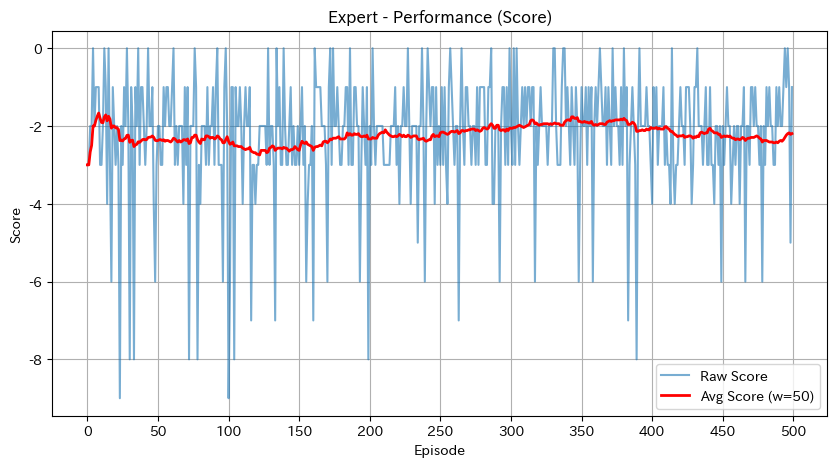

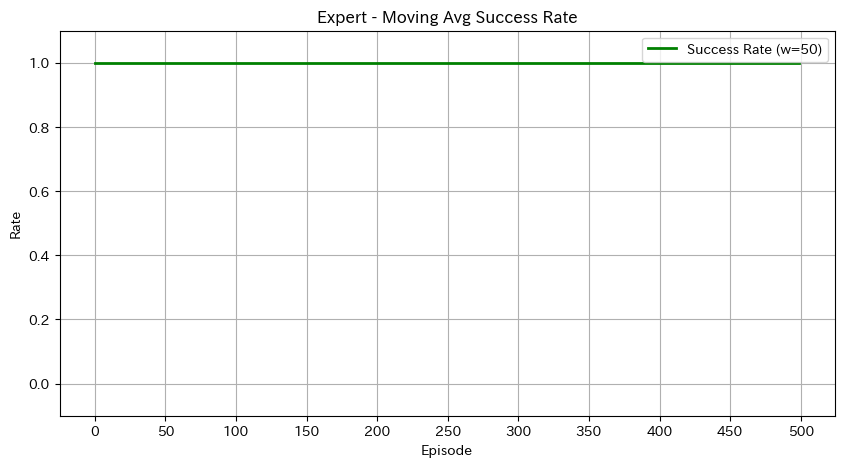

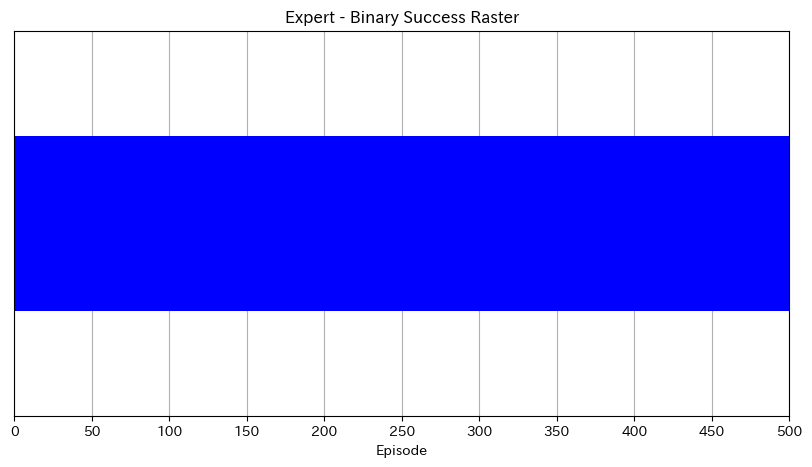

In [10]:
# 学習直後の軽量評価（平均報酬と成功率）
returns, successes = [], []
for _ in range(500):
    ep_ret, success = expert.test_model(env=env, steps=200, render_save_path=None)
    returns.append(ep_ret)
    successes.append(1 if success else 0)
mean_r = float(np.mean(returns))
succ = float(np.mean(successes) * 100)
print(f"IRL Expert 直後評価: 平均報酬 {mean_r:.3f}, 成功率 {succ:.1f}%")

# --- Plot Expert Baseline Immediately ---
# Use the 'successes' list populated above as the expert_history
print("Plotting Expert Baseline...")
try:
    # We pass empty list for all_results since Apprentice hasn't run yet
    plot_individual_performance("Expert", returns, successes)
except Exception as e:
    print(f"Expert plotting failed: {e}")


### IRLアルゴリズム

<div style="font-size: small;">

* 新規エージェントの学習では環境の既定報酬ではなく、IRLで推定したエキスパートの報酬関数を用いる。報酬は重み $w$ と観測特徴 $\Phi(s)$ によって与えられる。
* 特徴期待値 ($\mu(\pi)$): ポリシー $\pi$ に従うときの長期的な特徴ベクトルの期待値。
* エキスパートの特徴期待値 $\mu_E$ をモンテカルロ軌跡から推定できる。
* サンプル数 $m$ 本のエキスパート軌跡から得られる $\mu_E$ の経験的推定は次式:

$$\hat{\mu}_E = \frac{1}{m} \sum_{i=1}^m \sum_{t=0}^T \gamma^t \cdot \phi(\hat{s}^{(i)}_t)$$

</div>

In [11]:
expert = IRLTrainer(env=env, input_dims=obs_shape, agent_name='Expert', model_load_path='../IRL/Models/Expert/')


Loading models from ../IRL/Models/Expert/


In [12]:
def compute_average_feature(agent, m=2000):
        """
        m エピソードにわたって平均特徴ベクトル（特徴期待値）と平均報酬を計算する。
        """
        with torch.inference_mode():
            feature_sum, reward_sum = None, None

            for i in tqdm(range(m), desc='特徴ベクトルと報酬を計算中'):
                reward, success, states = agent.test_model(steps=1000, save_states=True)

                # エピソード全体の特徴ベクトルの平均
                episode_mean = torch.stack(states).mean(0)

                if feature_sum is None:
                    feature_sum, reward_sum = episode_mean, reward
                else:
                    feature_sum += episode_mean
                    reward_sum += reward

            # μ̂_E = (1/m) Σ_m Σ_t (γ^t φ(ŝ^(i)_t)) （γ ≈ 1 を仮定）
            feature_sum /= m
            reward_sum /= m

            print('\n特徴期待値: ',feature_sum)
            print('\n平均報酬: ',reward_sum)

        return feature_sum, reward_sum


In [13]:
expert_feature_expectation, expert_mean_reward = compute_average_feature(expert, m=1000)   # μ_E



特徴ベクトルと報酬を計算中: 100%|██████████| 1000/1000 [00:03<00:00, 271.29it/s]



特徴期待値:  tensor([[ 1.7687e-02,  4.6490e-03,  1.7431e-01, -2.2408e-01,  3.4820e-02,
         -1.4756e-01,  1.7687e-02,  4.6490e-03,  1.7431e-01,  1.1953e-04,
          1.9497e-03,  1.5581e-01]], device='cuda:0')

平均報酬:  -2.246


### 射影法によるIRLアルゴリズム

<div style="font-size: small;">

1. **初期化:**
   - 初期ポリシー $\pi^{(0)}$ をランダムに選ぶ。
   - モンテカルロなどで特徴期待値 $\mu^{(0)}$ を計算。
   - 反復カウンタ $i = 1$ に設定。

2. **マージン計算:**
   - 現在の特徴期待値と過去ポリシー群との最大マージン $t^{(i)}$ を計算。
   - 射影法で最適な重み $w^{(i)}$ を求める。

3. **終了判定:**
   - マージン $t^{(i)} \leq \epsilon$ なら終了。

4. **IRL学習:**
   - 重み $w^{(i)}$ による報酬でMDPを定義し、RLアルゴリズムで最適ポリシー $\pi^{(i)}$ を計算。

5. **特徴期待値の更新:**
   - 新ポリシー $\pi^{(i)}$ の特徴期待値 $\mu^{(i)}$ を推定。

6. **反復更新:**
   - 反復カウンタ $i$ をインクリメント。

7. **繰り返し:**
   - 手順2へ戻り、終了条件を満たすまで繰り返す。

終了後、$\{\pi^{(i)} : i = 0, \ldots, n\}$ のポリシー列がエキスパート挙動を近似する。

</div>

In [14]:

def calculate_chunked_stats(history, chunk_size=50):
    stats = []
    n = len(history)
    for i in range(0, n, chunk_size):
        chunk = history[i:i+chunk_size]
        success_count = sum(chunk)
        failure_count = len(chunk) - success_count
        success_rate = success_count / len(chunk) if chunk else 0
        stats.append({
            'chunk_idx': i // chunk_size,
            'start_episode': i,
            'end_episode': min(i + chunk_size, n) - 1,
            'success_count': success_count,
            'failure_count': failure_count,
            'success_rate': success_rate
        })
    return stats

def evaluate_agent(agent, env, episodes=50, steps=200):
    print(f"Evaluating agent for {episodes} episodes...")
    returns = []
    successes = []
    
    for _ in range(episodes):
        ep_ret, success = agent.test_model(env=env, steps=steps, render_save_path=None) # Ensure no render
        returns.append(ep_ret)
        successes.append(1 if success else 0)
    
    mean_return = np.mean(returns)
    std_return = np.std(returns)
    success_rate = np.mean(successes) * 100
    
    return mean_return, std_return, success_rate, successes, returns


In [ ]:
def projection_method_algorithm(env, expert_feature_expectation, expert_history=None, epsilon=0.001, m=2, n_episodes=500,
                                opt_steps=10, batch_size=256, exploration_period=125, save_render=False, fps=5, print_every=50):
    
    feature_expectation = []
    feature_expectation_bar = []
    weights = []
    margins = []
    rewards = []
    success_rates = []
    all_results = [] 
    
    obs_shape = env.observation_space['observation'].shape[0] + \
            env.observation_space['achieved_goal'].shape[0] + \
            env.observation_space['desired_goal'].shape[0]

    max_runs = 2
    
    for i in range(max_runs):
        current_exploration = 125 # Safety init
        print(f"\n-------------------------------------- Iteration: {i} --------------------------------------\n")
        if i == 0:
            phase_name = "Apprentice_Train"
            load_path = None
            save_path = "./Models/Apprentice_Train/"
            current_exploration = 125
        else:
            phase_name = "Apprentice_Trained"
            load_path = "./Models/Apprentice_Train/"
            save_path = "./Models/Apprentice_Trained/"
            current_exploration = 0
            
        print(f"Phase: {phase_name}, Load: {load_path}, Save: {save_path}, Expl: {current_exploration}")

        
        # Warm Start Logic: Load model from previous apprentice if available
        # i=0: Apprentice 0 (Fresh / Random)
        # i=1: Apprentice 1 (Load Apprentice 0)
        # Logic replaced below

        
        # Reduce exploration for transfer learning to exploit prior knowledge
        # Logic replaced below
        
        # Instantiate Trainer
        # Changed indexing to {i} to start at Apprentice 0
        apprentice = IRLTrainer(env=env, input_dims=obs_shape, agent_name=phase_name, 
                                model_save_path=save_path, 
                                model_load_path=load_path,
                                exploration_period=current_exploration,
                                batch_size=batch_size)
                                
        if i > 0 and load_path:
             print(f"Warm Start: Loaded model from {load_path}")

        # Step 1: Initialization / First Run (Apprentice 0)
        if i == 0:
            observation, info = env.reset()
            if isinstance(observation, dict):
                state = np.concatenate((observation['observation'], observation['achieved_goal'], observation['desired_goal']))
            else:
                state = observation
            sample_feature = torch.tensor(state, dtype=torch.float32)
            w_0 = torch.randn(sample_feature.size(0), 1).div_(torch.randn(1).norm())
            weights.append(w_0)
            
            score_hist, avg_score_hist, success_hist, avg_success_hist = apprentice.irl_train(
                n_episodes=n_episodes, opt_steps=opt_steps, 
                reward_weights=w_0, print_every=print_every, 
                plot_save_path=f'../Results/IRL/{phase_name}_Performance.png'
            )
            apprentice_feature_expectation, apprentice_reward = compute_average_feature(agent=apprentice, m=m)
            rewards.append(apprentice_reward)
            margins.append(1.0)
            feature_expectation.append(apprentice_feature_expectation)
            # print("Expert Feature Expectation:", expert_feature_expectation) 
            
        else:
            # Step 2: IRL Projection
            # Adjust indices because feature_expectation[0] corresponds to Apprentice 0 (i=0)
            if i == 1:
                feature_expectation_bar.append(feature_expectation[i - 1])
                weights.append((expert_feature_expectation - feature_expectation[i - 1]).view(-1, 1))
                margins.append((expert_feature_expectation - feature_expectation_bar[i - 1]).norm().item())
            else:
                A = feature_expectation_bar[i - 2]
                B = feature_expectation[i - 1] - A
                C = expert_feature_expectation - A
                numerator = (B.view(-1, 1).t() @ C.view(-1, 1))
                denominator = (B.view(-1, 1).t() @ B.view(-1, 1))
                if denominator == 0: denominator = 1e-8
                feature_expectation_bar.append(A + (numerator / denominator) * B)
                weight = (expert_feature_expectation - feature_expectation_bar[i - 1]).view(-1, 1)
                margin = (expert_feature_expectation - feature_expectation_bar[i - 1]).norm().item()
                weights.append(weight)
                margins.append(margin)
            print(f"Margin: {margins[i]}")
            if margins[i] <= epsilon:
                print(f"Converged with margin {margins[i]} <= {epsilon}")
                break

            score_hist, avg_score_hist, success_hist, avg_success_hist = apprentice.irl_train(
                n_episodes=n_episodes, opt_steps=opt_steps, 
                reward_weights=weights[-1], print_every=print_every, 
                plot_save_path=f'../Results/IRL/{phase_name}_Performance.png'
            )
            apprentice.save_model()
            
            if save_render:
                try:
                    apprentice.test_model(steps=1000, render_save_path=None)
                except Exception as e:
                    print(f"Rendering failed: {e}")

            apprentice_feature_expectation, apprentice_reward = compute_average_feature(agent=apprentice, m=m)
            rewards.append(apprentice_reward)
            feature_expectation.append(apprentice_feature_expectation)
            
        # --- Live Plotting & Results Collection ---
        final_sr = np.mean(success_hist[-100:]) * 100 if len(success_hist) >= 100 else 0.0
        success_rates.append(final_sr)
        print(f"Running Noise-Free Evaluation for {phase_name}...")
        eval_mean, eval_std, eval_sr, eval_succ_hist, eval_score_hist = evaluate_agent(apprentice, env, episodes=50, steps=200)
        print(f"{phase_name} Evaluation: Success Rate {eval_sr:.1f}%, Return {eval_mean:.1f}")
        

        res = {
            "id": i, "name": phase_name,
            "success_history": success_hist, "score_history": score_hist,
            "avg_success_history": avg_success_hist,
            "chunk_stats": calculate_chunked_stats(success_hist, chunk_size=50),
            "noise_free_success_rate": eval_sr, "eval_success_history": eval_succ_hist, "eval_score_history": eval_score_hist,
        }
        all_results.append(res)
        # --- Updated Plotting Logic ---
        try:
            # 1. Individual Plotting
            plot_label = phase_name
            curr_sc = score_hist if 'score_hist' in locals() else []
            curr_su = success_hist if 'success_hist' in locals() else []
            print(f'Plotting Individual Result for {plot_label}...')
            plot_individual_performance(plot_label, curr_su, curr_sc)
            
            # 2. Comparative Plotting
            if i == 0:
                 # Train vs Expert
                 print('Plotting Comparison: Apprentice_Train vs Expert_Train...')
                 # Use global history if available (Expert Training Data)
                 exp_sc = score_history if 'score_history' in locals() else []
                 exp_su = success_history if 'success_history' in locals() else []
                 plot_comparative_dashboard('Comparison (Train Phase)', 
                     {'name': 'Expert', 'scores': exp_sc, 'successes': exp_su}, 
                     [{'name': 'Apprentice_Train', 'scores': curr_sc, 'successes': curr_su}])
            else:
                 # Trained vs Expert
                 print('Plotting Comparison: Apprentice_Trained vs Expert_Eval...')
                 # Use expert_history arg (Eval Data)
                 exp_su = expert_history if expert_history is not None else []
                 plot_comparative_dashboard('Comparison (Trained Phase)', 
                     {'name': 'Expert', 'scores': [], 'successes': exp_su}, 
                     [{'name': 'Apprentice_Trained', 'scores': curr_sc, 'successes': curr_su}])

        except Exception as e:
            print(f'Plotting failed: {e}')
            import traceback
            traceback.print_exc()
        print(f"{phase_name} Final Avg Success Rate: {final_sr:.1f}%")
        print(f"\nDetailed Stats for {phase_name}:")
        stats = calculate_chunked_stats(success_hist, chunk_size=50)
        print(f"{'Chunk':<6} {'Range':<15} {'Success':<10} {'Fail':<10} {'Rate':<10}")
        print("-" * 60)
        for s in stats:
            range_str = f"{s['start_episode']}-{s['end_episode']}"
            print(f"{s['chunk_idx']:<6} {range_str:<15} {s['success_count']:<10} {s['failure_count']:<10} {s['success_rate']*100:>6.2f}%")
        print("")
        
        # --- NEW: Post-Training Evaluation (Noise-Free) ---
    return rewards, margins, success_rates, all_results


In [16]:
# Execute IRL projection method for auto runs

exp_hist = successes if 'successes' in locals() else []

# Settings updated per user request:
# - n_episodes: 500 
# - exploration_period: 7500 (150 episodes, 30% of total)
rewards, margins, success_rates, all_results = projection_method_algorithm(
    env, 
    expert_feature_expectation, 
    expert_history=exp_hist, 
    n_episodes=500, 
    m=2, 
    exploration_period=125
)

overall_success_rate = float(np.mean(success_rates)) if success_rates else 0.0
print(f"Overall success rate across {len(success_rates)} apprentices: {overall_success_rate:.1f}%")



-------------------------------------- Iteration: 0 --------------------------------------

Phase: Apprentice_Train, Load: None, Save: ./Models/Apprentice/, Expl: 125


Training..:   8%|▊         | 38/500 [00:06<01:17,  5.98it/s]


KeyboardInterrupt: 

In [ ]:
# Plot apprentice rewards with 1-indexed horizontal axis
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(rewards) + 1), rewards, marker='o')
plt.title('Average Episode Reward')
plt.xlabel('Apprentice Number')
plt.ylabel('Average Episode Reward')
plt.xticks(range(1, len(rewards) + 1))  # force integer ticks starting at 1
plt.savefig("../Results/IRL/Apprentice Rewards.png")
plt.show()

In [ ]:
# Plot Binary Success Events (Raster Plot)
# Shows exact success episodes for each model in a single graph
plt.figure(figsize=(12, 8))

# Prepare data for eventplot
success_events = []
colors = []
labels = []

# Use a colormap
cmap = plt.get_cmap('tab10')

# 1. Add Expert Data first (at the bottom or top? Let's put Expert at the top -> Index 0? or Max? 
# Usually baseline is at bottom or top. Let's put Expert at index -1 (bottom) or separate color.

# Expert
if 'expert_success_history' in locals() in locals() and expert_success_history:
    indices = [ep for ep, val in enumerate(expert_success_history) if val >= 0.9]
    success_events.append(indices)
    colors.append('black')  # Expert is black
    labels.append('Expert')

# 2. Add Apprentices
if any(all_results):
    for res in all_results:
        model_id = res['id']
        hist = res['success_history']
        indices = [ep for ep, val in enumerate(hist) if val >= 0.9]
        success_events.append(indices)
        colors.append(cmap(model_id % 10))
        labels.append(res['name']) if 'name' in res else labels.append(f'Apprentice_{model_id}')

# Plot
if success_events:
    plt.eventplot(success_events, lineoffsets=range(len(success_events)), 
                  linelengths=0.8, colors=colors, alpha=0.9)
    
    plt.title('Binary Success Events per Model inclusion Expert (Raster Plot)')
    plt.xlabel('Episode')
    plt.ylabel('Model')
    
    plt.yticks(range(len(labels)), labels)
    plt.ylim(-0.5, len(labels) - 0.5)
    plt.xlim(0, n_episodes)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("../Results/IRL/Apprentice_Trained_vs_Expert_Raster.png")
    plt.show()
else:
    print("No data to plot.")


In [ ]:
# Plot success rates to visualize progression over apprentices
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(success_rates) + 1), success_rates, marker='s', color='green')
plt.title('Apprentice Success Rate (Eval)')
plt.xlabel('Apprentice Number')
plt.ylabel('Success Rate (%)')
plt.ylim(0, 100)
plt.xticks(range(1, len(success_rates) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig("../Results/IRL/Apprentice Success Rates.png")
plt.show()


In [ ]:
# L2 policy error plotted with 1-indexed x-axis and clear labels
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Linear scale
axes[0].plot(range(1, len(margins) + 1), margins, label="$L_2$ Policy Error", marker='o')
axes[0].set_title("$L_2$ Policy Error")
axes[0].set_xlabel("Apprentice Number")
axes[0].set_ylabel("Squared Error of Features")
axes[0].set_xticks(range(1, len(margins) + 1))

# Log scale
axes[1].plot(range(1, len(margins) + 1), margins, label="$L_2$ Policy Error", marker='o')
axes[1].set_title("$L_2$ Policy Error (Log Scale)")
axes[1].set_xlabel("Apprentice Number")
axes[1].set_ylabel("Squared Error of Features")
axes[1].set_xticks(range(1, len(margins) + 1))
axes[1].set_yscale("log")

for ax in axes:

    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig("../Results/IRL/Apprentice Policy Error.png")
plt.show()


<div style="font-size: small;">

### 成功率による評価

`test_model()` が環境の `info['is_success']` を集計して返すようになったので、
累積報酬に閾値を設けずに成功率を評価できる。

</div>

In [ ]:

# IRL エキスパートを評価
expert_mean, expert_std, expert_sr = evaluate_agent(expert, env, episodes=10, steps=200)
print(f"IRL Expert:")
print(f"  平均報酬: {expert_mean:.3f} ± {expert_std:.3f}")
print(f"  成功率: {expert_sr:.1f}%")
